In [5]:
!pip install  matplotlib seaborn


CÁC MÔN ĐƯỢC SỬ DỤNG:

- Kỹ thuật lập trình nâng cao
- Trí tuệ nhân tạo và học máy
- Xử lý ảnh
- Thực tập chuyên ngành Công nghệ phần mềm
- Công nghệ phần mềm
- Quản lý dự án công nghệ thông tin

KẾT QUẢ PHÂN CỤM:

             MSSV      Tên sinh viên  Điểm TB phần mềm  \
0   K225480106002    Nguyễn Tuấn Anh          2.000000   
1   K225480106095    Nguyễn Tuấn Anh          2.400000   
2   K225510201001       Bùi Ngọc Anh          2.750000   
3   K225480106082        Vũ Việt Anh          3.000000   
4   K225480106001        Lê Tuấn Anh          2.916667   
..            ...                ...               ...   
66  K225480106067     Nguyễn Đình Tú          3.250000   
67  K225480106068          Vũ Đức Tú          2.916667   
68  K225480106075    Nguyễn Đức Việt          2.833333   
69  K225480106074  Nguyễn Hoàng Việt          3.316667   
70  K225480106073   Lương Hoàng Việt          3.550000   

                                      Nhóm  
0   Ít hứng thú hoặc học chưa tốt phần mềm

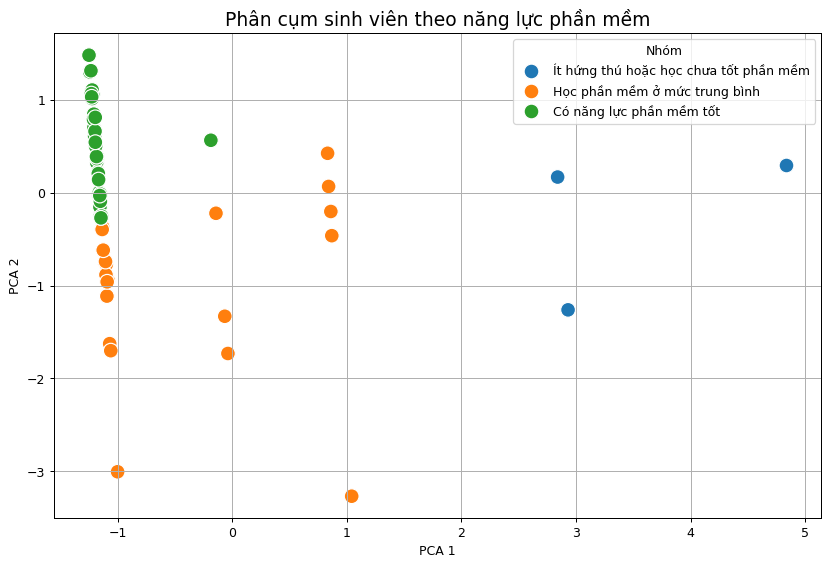


SỐ LƯỢNG SINH VIÊN MỖI NHÓM:

Nhóm
Có năng lực phần mềm tốt                  38
Học phần mềm ở mức trung bình             21
Ít hứng thú hoặc học chưa tốt phần mềm    12
Name: count, dtype: int64

Đã lưu file: phan_cum_nang_luc_phan_mem.xlsx


In [16]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# =====================================================
# 1. ĐỌC FILE EXCEL
# =====================================================

file_path = "K58KTP.xlsx"

raw_df = pd.read_excel(file_path, header=None)

# =====================================================
# 2. LẤY THÔNG TIN SINH VIÊN
# =====================================================

# MSSV nằm ở dòng 1
student_ids = raw_df.iloc[1, 3:].values

# Tên sinh viên nằm ở dòng 2
student_names = raw_df.iloc[2, 3:].values

# =====================================================
# 3. LẤY DỮ LIỆU MÔN HỌC
# =====================================================

# Từ dòng 4 trở đi là dữ liệu môn học
subject_df = raw_df.iloc[4:, :]

# Lấy mã môn
subject_codes = subject_df.iloc[:, 1].values

# Lấy tên môn
subject_names = subject_df.iloc[:, 2].values

# Lấy bảng điểm
score_data = subject_df.iloc[:, 3:]

# =====================================================
# 4. DÙNG TÊN MÔN HỌC LÀM INDEX
# =====================================================

score_data.index = subject_names

# =====================================================
# 5. CHUYỂN DỮ LIỆU SANG SỐ
# =====================================================

score_data = score_data.apply(
    pd.to_numeric,
    errors='coerce'
)

# =====================================================
# 7. CHỌN CÁC MÔN LIÊN QUAN PHẦN MỀM
# =====================================================

software_subjects = [

    'Kỹ thuật lập trình nâng cao',

    'Trí tuệ nhân tạo và học máy',

    'Xử lý ảnh',

    'Thực tập chuyên ngành Công nghệ phần mềm',

    'Công nghệ phần mềm',

    'Quản lý dự án công nghệ thông tin'

]

# =====================================================
# 8. KIỂM TRA MÔN TỒN TẠI
# =====================================================

available_subjects = []

for subject in software_subjects:

    if subject in score_data.index:

        available_subjects.append(subject)

print("\nCÁC MÔN ĐƯỢC SỬ DỤNG:\n")

for subject in available_subjects:
    print("-", subject)

# =====================================================
# 9. LẤY ĐIỂM CÁC MÔN PHẦN MỀM
# =====================================================

software_scores = score_data.loc[available_subjects]

# =====================================================
# 10. CHUYỂN MA TRẬN
# hàng = sinh viên
# cột = môn học
# =====================================================

student_scores = software_scores.T

student_scores.columns = available_subjects

# =====================================================
# 11. TẠO FEATURE:
# SỐ MÔN THIẾU ĐIỂM
# =====================================================

student_scores['Missing_Count'] = (
    student_scores.isna().sum(axis=1)
)

# =====================================================
# 12. XỬ LÝ GIÁ TRỊ THIẾU
# =====================================================

imputer = SimpleImputer(strategy='mean')

X = imputer.fit_transform(student_scores)

# =====================================================
# 13. PHÂN CỤM KMEANS
# =====================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

# =====================================================
# 14. TẠO BẢNG KẾT QUẢ
# =====================================================

result_df = pd.DataFrame({

    'MSSV': student_ids,

    'Tên sinh viên': student_names,

    'Cụm': clusters

})

# =====================================================
# 15. TÍNH ĐIỂM TB PHẦN MỀM
# =====================================================

result_df['Điểm TB phần mềm'] = (

    student_scores
    .drop(columns=['Missing_Count'])
    .mean(axis=1)
    .values

)

# =====================================================
# 16. PHÂN TÍCH CỤM
# =====================================================

cluster_mean = (

    result_df
    .groupby('Cụm')['Điểm TB phần mềm']
    .mean()

)

sorted_clusters = (

    cluster_mean
    .sort_values(ascending=False)
    .index
)

# =====================================================
# 17. ĐẶT TÊN NHÓM
# =====================================================

cluster_labels = {

    sorted_clusters[0]:
    'Có năng lực phần mềm tốt',

    sorted_clusters[1]:
    'Học phần mềm ở mức trung bình',

    sorted_clusters[2]:
    'Ít hứng thú hoặc học chưa tốt phần mềm'

}

result_df['Nhóm'] = (
    result_df['Cụm']
    .map(cluster_labels)
)

# =====================================================
# 18. HIỂN THỊ KẾT QUẢ
# =====================================================

print("\nKẾT QUẢ PHÂN CỤM:\n")

print(

    result_df[
        [
            'MSSV',
            'Tên sinh viên',
            'Điểm TB phần mềm',
            'Nhóm'
        ]
    ]

)

# =====================================================
# 19. PCA GIẢM CHIỀU
# =====================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plot_df = pd.DataFrame({

    'PCA1': X_pca[:, 0],

    'PCA2': X_pca[:, 1],

    'Nhóm': result_df['Nhóm']

})

# =====================================================
# 20. TRỰC QUAN HÓA
# =====================================================

plt.figure(figsize=(11, 7), dpi=90)

sns.scatterplot(

    data=plot_df,

    x='PCA1',

    y='PCA2',

    hue='Nhóm',

    s=140

)

plt.title(
    'Phân cụm sinh viên theo năng lực phần mềm',
    fontsize=15
)

plt.xlabel('PCA 1')

plt.ylabel('PCA 2')

plt.grid(True)

plt.show()

# =====================================================
# 21. THỐNG KÊ SỐ LƯỢNG
# =====================================================

print("\nSỐ LƯỢNG SINH VIÊN MỖI NHÓM:\n")

print(
    result_df['Nhóm']
    .value_counts()
)

# =====================================================
# 22. LƯU FILE KẾT QUẢ
# =====================================================

result_df.to_excel(
    'phan_cum_nang_luc_phan_mem.xlsx',
    index=False
)

print(
    "\nĐã lưu file: phan_cum_nang_luc_phan_mem.xlsx"
)